# Signal-level Monte Carlo для GCC-PHAT и WLS DOA

Модель шума диагностическая: независимый по каналам и отсчётам Gaussian noise. Для каждого канала $\mathrm{SNR}=20\log_{10}(\mathrm{RMS}_{signal}/\sigma_{noise})$, где RMS измерен в общем valid region чистых каналов. Это не измеренная модель БПЛА. SRP-PHAT, отражения, ветер и движение отсутствуют.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
from validation.gcc_monte_carlo import (
    GCC_MONTE_CARLO_SEED, GCC_MONTE_CARLO_TRIALS,
    run_gcc_phat_monte_carlo,
)
plt.rcParams['figure.figsize'] = (8, 4.5)

## План эксперимента

Используются square/tetrahedral, направления 20°/10°, 45°/30°, 120°/50°, SNR −20…20 dB и 200 реализаций. После детерминированного cross-generator аудита массовый синтез выполняется Kaiser FIR; frequency-domain остаётся эталоном. Оцениваются три линейно независимых опорных TDOA относительно микрофона 0. Равные веса WLS — явное допущение; signal-level CRLB здесь не заявляется.

In [2]:
rows = run_gcc_phat_monte_carlo(output_csv=ROOT/'results/gcc_phat_monte_carlo.csv')
print(f'configurations={len(rows)}, total trials={sum(r["trial_count"] for r in rows)}, base seed={GCC_MONTE_CARLO_SEED}')
print('SNR levels:', sorted({r['snr_db'] for r in rows}))

configurations=36, total trials=7200, base seed=20260827
SNR levels: [-20.0, -10.0, 0.0, 5.0, 10.0, 20.0]


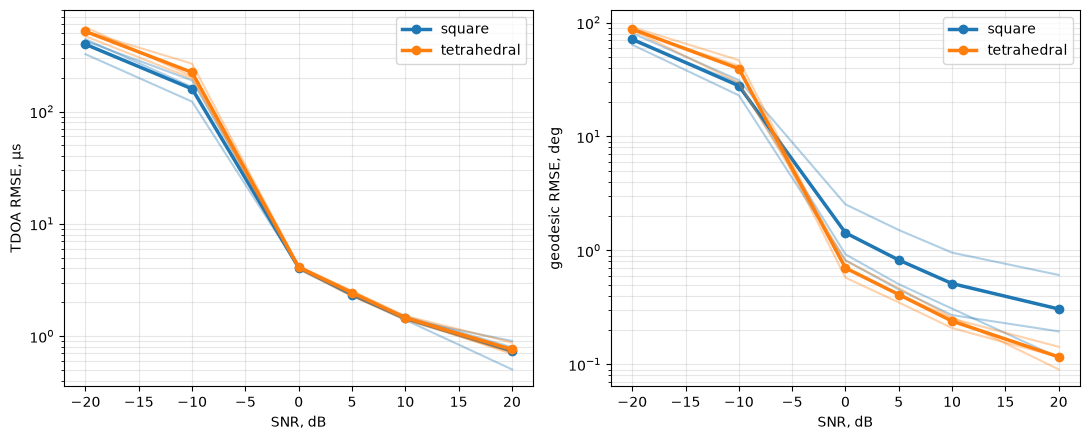

In [3]:
snrs = sorted({float(r['snr_db']) for r in rows})
directions = sorted({(float(r['azimuth_deg']), float(r['elevation_deg'])) for r in rows})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for geometry, color in [('square','tab:blue'), ('tetrahedral','tab:orange')]:
    for direction in directions:
        subset = [r for r in rows if r['geometry']==geometry and (r['azimuth_deg'],r['elevation_deg'])==direction]
        subset.sort(key=lambda r:r['snr_db'])
        axes[0].semilogy(snrs, [r['tdoa_rmse_us'] for r in subset], color=color, alpha=.35)
        axes[1].semilogy(snrs, [r['geodesic_rmse_deg'] for r in subset], color=color, alpha=.35)
    mean_tdoa = [np.mean([r['tdoa_rmse_us'] for r in rows if r['geometry']==geometry and r['snr_db']==snr]) for snr in snrs]
    mean_geo = [np.mean([r['geodesic_rmse_deg'] for r in rows if r['geometry']==geometry and r['snr_db']==snr]) for snr in snrs]
    axes[0].semilogy(snrs, mean_tdoa, 'o-', color=color, lw=2.5, label=geometry)
    axes[1].semilogy(snrs, mean_geo, 'o-', color=color, lw=2.5, label=geometry)
axes[0].set_ylabel('TDOA RMSE, µs'); axes[1].set_ylabel('geodesic RMSE, deg')
for ax in axes: ax.set_xlabel('SNR, dB'); ax.grid(True, which='both', alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

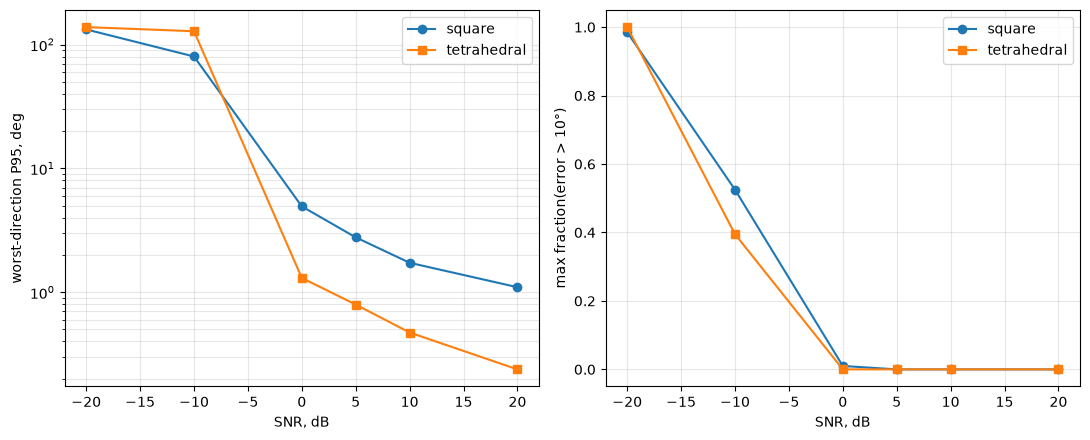

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for geometry, marker in [('square','o'), ('tetrahedral','s')]:
    p95 = [max(r['p95_geodesic_error_deg'] for r in rows if r['geometry']==geometry and r['snr_db']==snr) for snr in snrs]
    tail = [max(r['fraction_geodesic_error_gt_10deg'] for r in rows if r['geometry']==geometry and r['snr_db']==snr) for snr in snrs]
    axes[0].semilogy(snrs, p95, marker=marker, label=geometry)
    axes[1].plot(snrs, tail, marker=marker, label=geometry)
axes[0].set_ylabel('worst-direction P95, deg'); axes[1].set_ylabel('max fraction(error > 10°)')
for ax in axes: ax.set_xlabel('SNR, dB'); ax.grid(True, which='both', alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

In [5]:
for geometry in ('square','tetrahedral'):
    print('\n', geometry)
    for snr in snrs:
        subset=[r for r in rows if r['geometry']==geometry and r['snr_db']==snr]
        print(f"{snr:>5.0f} dB: mean TDOA RMSE={np.mean([r['tdoa_rmse_us'] for r in subset]):7.3f} µs, mean geodesic RMSE={np.mean([r['geodesic_rmse_deg'] for r in subset]):6.3f}°, max P95={max(r['p95_geodesic_error_deg'] for r in subset):6.3f}°")


 square
  -20 dB: mean TDOA RMSE=396.738 µs, mean geodesic RMSE=71.329°, max P95=132.541°
  -10 dB: mean TDOA RMSE=158.991 µs, mean geodesic RMSE=27.845°, max P95=80.115°
    0 dB: mean TDOA RMSE=  4.072 µs, mean geodesic RMSE= 1.427°, max P95= 4.932°
    5 dB: mean TDOA RMSE=  2.334 µs, mean geodesic RMSE= 0.823°, max P95= 2.774°
   10 dB: mean TDOA RMSE=  1.438 µs, mean geodesic RMSE= 0.511°, max P95= 1.729°
   20 dB: mean TDOA RMSE=  0.735 µs, mean geodesic RMSE= 0.306°, max P95= 1.097°

 tetrahedral
  -20 dB: mean TDOA RMSE=516.366 µs, mean geodesic RMSE=87.563°, max P95=138.356°
  -10 dB: mean TDOA RMSE=223.062 µs, mean geodesic RMSE=39.346°, max P95=128.141°
    0 dB: mean TDOA RMSE=  4.102 µs, mean geodesic RMSE= 0.701°, max P95= 1.304°
    5 dB: mean TDOA RMSE=  2.431 µs, mean geodesic RMSE= 0.410°, max P95= 0.795°
   10 dB: mean TDOA RMSE=  1.456 µs, mean geodesic RMSE= 0.239°, max P95= 0.473°
   20 dB: mean TDOA RMSE=  0.761 µs, mean geodesic RMSE= 0.116°, max P95= 0.238°


## Интерпретация

При SNR ≥ 0 dB корреляционный максимум устойчив для выбранного broadband-сигнала; tetrahedral преобразует TDOA-ошибки в углы заметно устойчивее square. При −10 dB возникает смесь правильных и ложных максимумов, а при −20 dB GCC практически сорван. Формальный success оптимизатора WLS не обнаруживает ложный максимум GCC, поэтому нужны tail/outlier метрики.

In [6]:
assert len(rows) == 36 and sum(r['trial_count'] for r in rows) == 7200
assert all(np.isfinite(float(value)) for r in rows for key,value in r.items() if isinstance(value,(int,float)))
high = [r for r in rows if r['snr_db']==20.0]
zero = [r for r in rows if r['snr_db']==0.0]
assert max(r['tdoa_rmse_us'] for r in high) < 1.0
assert max(r['geodesic_rmse_deg'] for r in high) < 1.0
assert max(r['fraction_geodesic_error_gt_10deg'] for r in high) == 0.0
assert max(r['geodesic_rmse_deg'] for r in zero) < 3.0
assert min(r['wls_success_fraction'] for r in rows) == 1.0
print('Monte Carlo acceptance passed. No CRLB comparison is claimed for this signal-level noise model.')

Monte Carlo acceptance passed. No CRLB comparison is claimed for this signal-level noise model.
